In [64]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    f1_score
)

from xgboost import XGBClassifier

In [65]:
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [66]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target_original'] = data.target

df['target'] = 1 - df['target_original']

df['target_name'] = df['target'].map({
    0: 'benign',
    1: 'malignant'
})

print('데이터 크기 (행, 열):', df.shape)

데이터 크기 (행, 열): (569, 33)


In [67]:
df[['target_original', 'target', 'target_name']].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [68]:
df['target_name'].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [69]:
X = df.drop(columns=['target_original', 'target', 'target_name'])

y = df['target']

print('X의 열 개수:', X.shape[1])
print('정답 관련 컬럼이 X에 있나요?',
      any(col in X.columns for col in ['target_original', 'target', 'target_name']))

X의 열 개수: 30
정답 관련 컬럼이 X에 있나요? False


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('학습용 데이터 개수:', X_train.shape[0])
print('평가용 데이터 개수:', X_test.shape[0])

학습용 데이터 개수: 455
평가용 데이터 개수: 114


In [71]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

print('예측 완료! 예측한 데이터 개수:', len(y_pred))
print('예측값 예시 (앞 10개):', y_pred[:10])
print('malignant 확률 예시 (앞 5개):', y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수: 114
예측값 예시 (앞 10개): [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개): [0.001 1.    0.04  0.993 0.017]


In [72]:
accuracy = accuracy_score(y_test, y_pred)

print('accuracy:', accuracy)
print(f'즉, 전체의 약 {accuracy*100:.1f}%를 맞혔습니다.')

accuracy: 0.9736842105263158
즉, 전체의 약 97.4%를 맞혔습니다.


In [73]:
class_names = ['benign', 'malignant']

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

[[72  0]
 [ 3 39]]


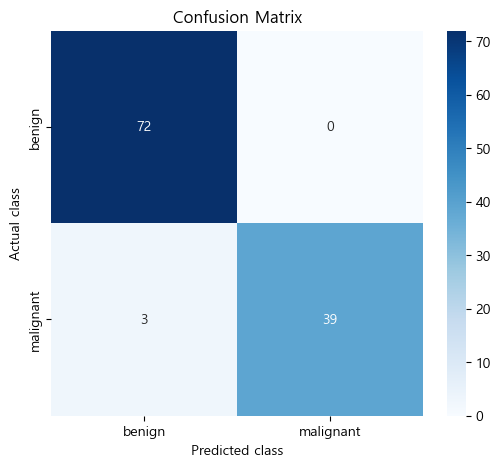

In [74]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion Matrix')
plt.show()

In [75]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [76]:
X_test_reset = X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)

result_df = X_test_reset.copy()

result_df['y_true'] = y_test_reset
result_df['y_pred'] = y_pred

result_df['malignant_probability'] = y_pred_proba

In [77]:
result_df['y_true_name'] = result_df['y_true'].map({0: 'benign', 1: 'malignant'})
result_df['y_pred_name'] = result_df['y_pred'].map({0: 'benign', 1: 'malignant'})

result_df['is_correct'] = result_df['y_true'] == result_df['y_pred']

result_df[['y_true', 'y_pred', 'y_true_name', 'y_pred_name', 'malignant_probability', 'is_correct']].head()

,y_true,y_pred,y_true_name,y_pred_name,malignant_probability,is_correct
0,0,0,benign,benign,0.001136,True
1,1,1,malignant,malignant,0.999783,True
2,0,0,benign,benign,0.039927,True
3,1,1,malignant,malignant,0.993436,True
4,0,0,benign,benign,0.016957,True


In [78]:
wrong_df = result_df[result_df['is_correct'] == False]

print('틀린 예측 개수:', len(wrong_df))

if len(wrong_df) == 0:
    print('이번 test split에서는 틀린 예측이 발생하지 않았습니다.')
else:
    important_columns = [
        'y_true_name',
        'y_pred_name',
        'malignant_probability',
        'mean radius',
        'mean perimeter',
        'mean area',
        'worst radius',
        'worst perimeter',
        'worst area',
        'worst concave points'
    ]
    
    available_colums = [col for col in important_columns if col in wrong_df.columns]
    
    display(wrong_df[available_colums].round(3))

틀린 예측 개수: 3


,y_true_name,y_pred_name,malignant_probability,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area,worst concave points
16,malignant,benign,0.003,13.80,90.43,584.1,16.57,110.3,812.4,0.138
69,malignant,benign,0.377,12.45,82.57,477.1,15.47,103.4,741.6,0.174
112,malignant,benign,0.261,15.12,98.78,716.6,17.77,117.7,989.5,0.125


In [79]:
# False Negative(FN): 실제 악성이지만 양성으로 예측
false_negative_df = result_df[
    (result_df['y_true'] == 1) &
    (result_df['y_pred'] == 0)
]

print('False Negative 개수:', len(false_negative_df))

if len(false_negative_df) == 0:
    print('이번 test split에서는 false negative가 발생하지 않았습니다.')
else:
    display(false_negative_df[['y_true_name', 'y_pred_name']])

False Negative 개수: 3


,y_true_name,y_pred_name
16,malignant,benign
69,malignant,benign
112,malignant,benign


In [80]:
# False Positive(FP): 실제 양성이지만 악성으로 예측
false_positive_df = result_df[
    (result_df['y_true'] == 0) &
    (result_df['y_pred'] == 1)
]

print('False Positive 개수:', len(false_positive_df))

if len(false_positive_df) == 0:
    print('이번 test split에서는 false positive가 발생하지 않았습니다.')
else:
    display(false_positive_df[['y_true_name', 'y_pred_name']])

False Positive 개수: 0
이번 test split에서는 false positive가 발생하지 않았습니다.


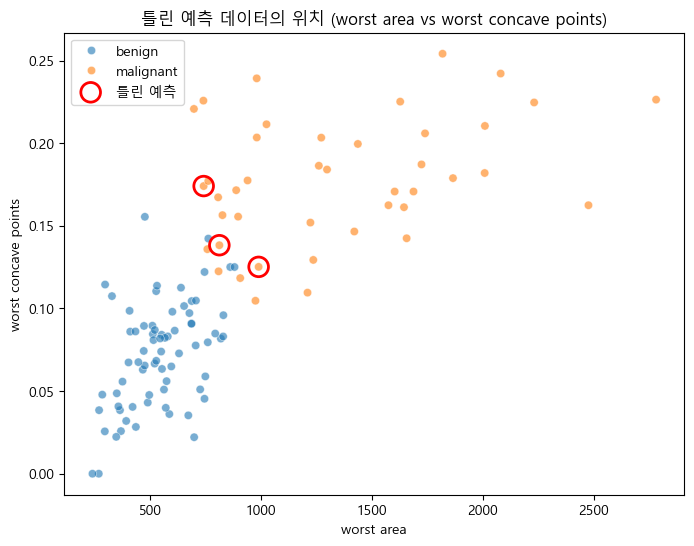

In [81]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=result_df,
    x='worst area',
    y='worst concave points',
    hue='y_true_name',
    alpha=0.6
)

if len(wrong_df) > 0:
    plt.scatter(
        wrong_df['worst area'],
        wrong_df['worst concave points'],
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='틀린 예측'
    )
else:
    print('이번 test split에서는 틀린 예측이 없어 별도로 표시할 점이 없습니다.')

plt.title('틀린 예측 데이터의 위치 (worst area vs worst concave points)')
plt.xlabel('worst area')
plt.ylabel('worst concave points')
plt.legend()
plt.show()

In [82]:
# 차원 축소 간단한 예시
scaler_exam_df = pd.DataFrame({
    'house_price': [120000, 115000, 10000, 110000, 119000], # 단위가 크므로 조금만 잘못 예측해도 큰 차이가 남 -> 모델이 여기에 집중
    'owner_age': [24, 38, 65, 42, 52],
    'is_sale_next_month': [0, 1, 0, 1, 1]
})

scaler_exam_df

,house_price,owner_age,is_sale_next_month
0,120000,24,0
1,115000,38,1
2,10000,65,0
3,110000,42,1
4,119000,52,1


In [83]:
scaler_exam_df[['house_price', 'owner_age']].mean()

house_price    94800.0
owner_age         44.2
dtype: float64

In [84]:
scaler_exam_df[['house_price', 'owner_age']].std()

house_price    47567.846283
owner_age         15.368800
dtype: float64

In [85]:
(scaler_exam_df[['house_price', 'owner_age']] - scaler_exam_df[['house_price', 'owner_age']].mean()) \
    / scaler_exam_df[['house_price', 'owner_age']].std()

,house_price,owner_age
0,0.529770,-1.314351
1,0.424657,-0.403415
2,-1.782717,1.353391
3,0.319544,-0.143147
4,0.508747,0.507522


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler_exam_df[['house_price', 'owner_age']]

,house_price,owner_age
0,120000,24
1,115000,38
2,10000,65
3,110000,42
4,119000,52


In [87]:
scaler.fit(scaler_exam_df[['house_price', 'owner_age']])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [88]:
scaler.transform(scaler_exam_df[['house_price', 'owner_age']])

array([[ 0.59230044, -1.4694893 ],
       [ 0.47478052, -0.45103137],
       [-1.99313801,  1.5131375 ],
       [ 0.35726059, -0.16004339],
       [ 0.56879646,  0.56742656]])

In [89]:
X_train_scaled.shape

(455, 30)

In [90]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('PCA 변환 후 학습용 데이터 shape:', X_train_pca.shape)
print('PCA 변환 후 평가용 데이터 shape:', X_test_pca.shape)

print('PC1 설명 분산 비율:', round(pca.explained_variance_ratio_[0], 3))
print('PC2 설명 분산 비율:', round(pca.explained_variance_ratio_[1], 3))
print('PC1 + PC2 설명 분산 비율:', round(pca.explained_variance_ratio_.sum(), 3))


PCA 변환 후 학습용 데이터 shape: (455, 2)
PCA 변환 후 평가용 데이터 shape: (114, 2)
PC1 설명 분산 비율: 0.446
PC2 설명 분산 비율: 0.185
PC1 + PC2 설명 분산 비율: 0.631


In [91]:
pca_df = pd.DataFrame({
    'PC1': X_test_pca[:, 0],
    'PC2': X_test_pca[:, 1],
    'y_true': y_test.values,
    'y_pred': y_pred,
    'malignant_probability': y_pred_proba    
})

pca_df['y_true_name'] = pca_df['y_true'].map({
    0: 'benign',
    1: 'malignant'
})

pca_df['y_pred_name'] = pca_df['y_pred'].map({
    0: 'benign',
    1: 'malignant'
})

pca_df['is_correct'] = pca_df['y_true'] == pca_df['y_pred']

pca_df.head()

,PC1,PC2,y_true,y_pred,malignant_probability,y_true_name,y_pred_name,is_correct
0,-2.954871,0.471308,0,0,0.001136,benign,benign,True
1,6.892485,-2.047321,1,1,0.999783,malignant,malignant,True
2,-0.125826,-0.058798,0,0,0.039927,benign,benign,True
3,0.586226,0.666002,1,1,0.993436,malignant,malignant,True
4,-1.868729,-1.530491,0,0,0.016957,benign,benign,True


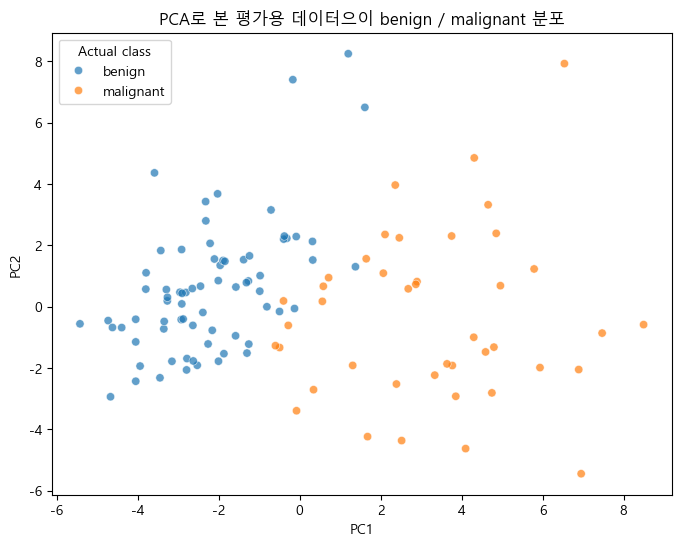

In [92]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='y_true_name',
    alpha=0.7
)

plt.title('PCA로 본 평가용 데이터으이 benign / malignant 분포')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Actual class')
plt.show()

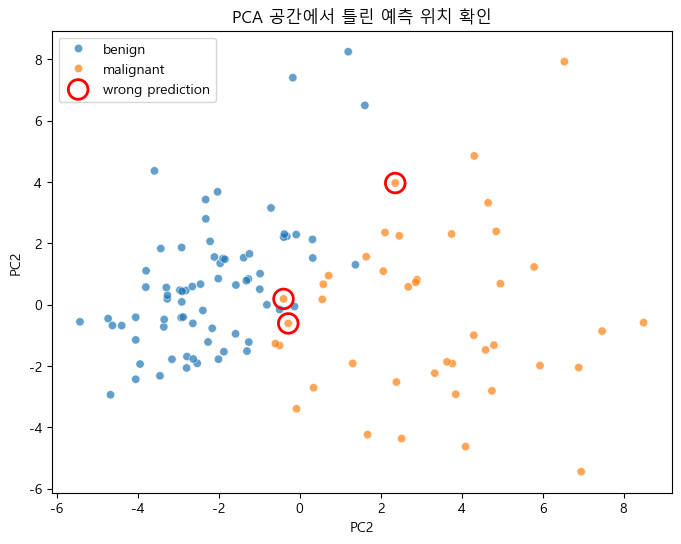

In [93]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='y_true_name',
    alpha=0.7
)

wrong_pca_df = pca_df[pca_df['is_correct'] == False]

if len(wrong_pca_df) > 0:
    plt.scatter(
        wrong_pca_df['PC1'],
        wrong_pca_df['PC2'],
        s=200,
        facecolors='none',
        edgecolors='red',
        linewidths=2,
        label='wrong prediction'
    )

plt.title('PCA 공간에서 틀린 예측 위치 확인')
plt.xlabel('PC1')
plt.xlabel('PC2')
plt.legend()
plt.show()

In [94]:
from sklearn.metrics import confusion_matrix, classification_report

threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

In [95]:
for threshold in threshold_list:
    print('=' * 30)
    print(f'threshold={threshold}')
    print('=' * 70)
    
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    print(f'y_pred_threshold={y_pred_threshold[:20]}')
    
    cm_threshold = confusion_matrix(y_test, y_pred_threshold, labels=[0, 1])
    print(f'cm_threshold={cm_threshold}')
    
    print('\nClassification Report')
    print(
        classification_report(y_test, y_pred_threshold, labels=[0, 1], target_names=['benign', 'malignant'])
    )
    print('=' * 30)

threshold=0.5
y_pred_threshold=[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]
cm_threshold=[[72  0]
 [ 3 39]]

Classification Report
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

threshold=0.4
y_pred_threshold=[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]
cm_threshold=[[72  0]
 [ 3 39]]

Classification Report
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

threshold=0.3
y_pred_threshold=[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]
cm_threshold=[[72

In [96]:
y_pred_proba

array([1.13609107e-03, 9.99782741e-01, 3.99268866e-02, 9.93436217e-01,
       1.69566628e-02, 1.00996264e-03, 8.67667556e-01, 9.96995135e-04,
       9.41021790e-05, 1.81898227e-04, 9.81809974e-01, 1.55503990e-03,
       9.99786794e-01, 5.24819421e-04, 2.20141985e-04, 1.16337265e-04,
       2.65839673e-03, 3.51775787e-04, 1.02739390e-02, 6.46480534e-04,
       2.64419429e-03, 5.92395663e-04, 9.99816835e-01, 9.99395609e-01,
       5.56348681e-01, 1.64135359e-04, 8.20630870e-04, 9.21686172e-01,
       9.99478281e-01, 9.99539733e-01, 9.99568284e-01, 7.11447268e-04,
       9.99835610e-01, 9.99239326e-01, 3.98001139e-04, 1.77244016e-04,
       9.41150138e-05, 6.63086903e-05, 9.82604444e-01, 2.05296301e-03,
       4.27948032e-03, 8.50411307e-04, 6.36209905e-01, 2.16234243e-03,
       1.81187484e-02, 9.99601662e-01, 7.48542976e-03, 9.99061644e-01,
       3.58641800e-03, 3.75042058e-04, 9.98892844e-01, 9.99558270e-01,
       3.23750864e-04, 4.45929589e-03, 1.89055965e-04, 9.06293452e-01,
      

In [97]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

In [98]:
fpr

array([0.  , 0.  , 0.  , 0.25, 0.25, 1.  ])

In [99]:
tpr

array([0.        , 0.02380952, 0.97619048, 0.97619048, 1.        ,
       1.        ])

In [100]:
threshold

array([           inf, 9.99835610e-01, 2.60724038e-01, 2.99005839e-03,
       2.65839673e-03, 4.52879540e-05])

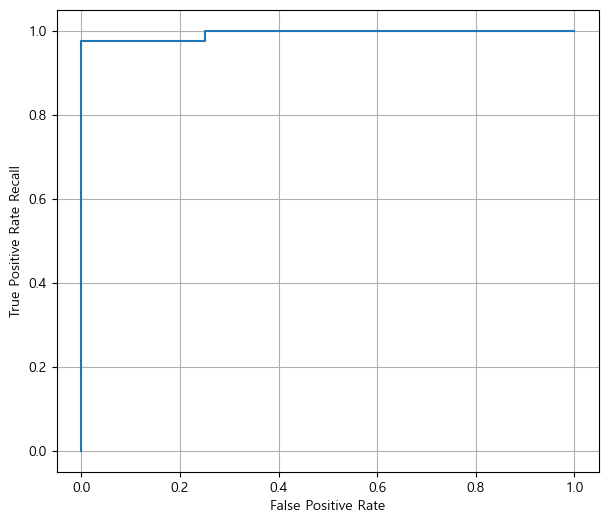

In [101]:
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate Recall')
plt.grid(True)